In [27]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [28]:
# Paramètres globaux
IMG_SIZE = (28, 28)  # Taille des images
BATCH_SIZE = 32
EPOCHS = 10
DATASET_PATH = "DataGenLett"  # Chemin vers le dataset

In [29]:
def clean_image(image, target_size):
    """
    Nettoie et prétraite une image pour la réduire au bruit et ajuster la taille.
    """
    img_resized = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)
    blurred = cv2.GaussianBlur(img_resized, (5, 5), 0)
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return binary

In [30]:
def loadset(path_name, img_size=(28, 28), grayscale=True, num_images=None):
    """
    Charge et prétraite les images d'un chemin spécifié, qui contient des sous-dossiers de classes.
    """
    X = []
    Y = []
    class_indices = {}
    
    class_names = sorted(os.listdir(path_name))
    class_indices = {name: idx for idx, name in enumerate(class_names)}
    
    for class_name, class_index in class_indices.items():
        class_path = os.path.join(path_name, class_name)
        if not os.path.exists(class_path):
            print(f"⚠ Le dossier {class_path} n'existe pas, il sera ignoré.")
            continue
        if os.path.isdir(class_path):
            images = os.listdir(class_path)
            if num_images:
                images = images[:num_images]
            
            image_count = 0
            for img_name in images:
                img_path = os.path.join(class_path, img_name)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE if grayscale else cv2.IMREAD_COLOR)
                
                if img is None:
                    print(f"⚠ Impossible de lire {img_path}, il sera ignoré.")
                    continue
                
                img_processed = clean_image(img, img_size)
                X.append(img_processed)
                Y.append(class_index)
                image_count += 1
            
            print(f"> 📂 Classe {class_name} ({class_index}) chargée avec {image_count} images.")
        else:
            print(f"⚠ {class_path} n'est pas un dossier.")
    
    print("\n✅ Chargement terminé !")
    return np.array(X), np.array(Y), class_indices

In [31]:
# Chargement des données
X, Y, class_indices = loadset(DATASET_PATH, img_size=IMG_SIZE, grayscale=True, num_images=1000)
X, Y = shuffle(X, Y, random_state=42)
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)  # 30% pour val+test
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)  # 15% val, 15% test

⚠ DataGenLett/.DS_Store n'est pas un dossier.
⚠ Impossible de lire DataGenLett/a/.DS_Store, il sera ignoré.
> 📂 Classe a (1) chargée avec 999 images.
> 📂 Classe b (2) chargée avec 1000 images.
> 📂 Classe c (3) chargée avec 1000 images.
> 📂 Classe d (4) chargée avec 1000 images.
> 📂 Classe dd (5) chargée avec 1000 images.
> 📂 Classe e (6) chargée avec 1000 images.
> 📂 Classe f (7) chargée avec 1000 images.
> 📂 Classe g (8) chargée avec 1000 images.
> 📂 Classe h (9) chargée avec 1000 images.
> 📂 Classe i (10) chargée avec 1000 images.
> 📂 Classe j (11) chargée avec 1000 images.
> 📂 Classe k (12) chargée avec 1000 images.
> 📂 Classe l (13) chargée avec 1000 images.
> 📂 Classe m (14) chargée avec 1000 images.
> 📂 Classe n (15) chargée avec 1000 images.
⚠ Impossible de lire DataGenLett/o/o1_213.jpg, il sera ignoré.
> 📂 Classe o (16) chargée avec 999 images.
⚠ Impossible de lire DataGenLett/p/p2_103.jpg, il sera ignoré.
⚠ Impossible de lire DataGenLett/p/p5_188.jpg, il sera ignoré.
> 📂 Class

In [32]:
print("Forme des ensembles :")
print(f"Train: {X_train.shape}, {Y_train.shape}")
print(f"Validation: {X_val.shape}, {Y_val.shape}")
print(f"Test: {X_test.shape}, {Y_test.shape}")

Forme des ensembles :
Train: (21405, 28, 28), (21405,)
Validation: (4587, 28, 28), (4587,)
Test: (4587, 28, 28), (4587,)


In [76]:
# Création du modèle
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),  # Assurez-vous que la dimension est correcte pour des images en niveaux de gris
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_indices), activation='softmax')
])
# Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [34]:
# Entraînement du modèle
history = model.fit(
    X_train, Y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, Y_val)  # Utilisation de l'ensemble de validation
)

# Évaluation du modèle sur l'ensemble de test
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=2)
print(f"\nPrécision sur l'ensemble de test : {test_acc:.4f}")

Epoch 1/10
669/669 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.2668 - loss: 4.2441 - val_accuracy: 0.9172 - val_loss: 0.2079
Epoch 2/10
669/669 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.8587 - loss: 0.3710 - val_accuracy: 0.9645 - val_loss: 0.0917
Epoch 3/10
669/669 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9218 - loss: 0.2108 - val_accuracy: 0.9610 - val_loss: 0.0856
Epoch 4/10
669/669 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.9415 - loss: 0.1480 - val_accuracy: 0.9782 - val_loss: 0.0479
Epoch 5/10
669/669 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9510 - loss: 0.1313 - val_accuracy: 0.9771 - val_loss: 0.0590
Epoch 6/10
669/669 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.9621 - loss: 0.0961 - val_accuracy: 0.9708 - val_loss: 0.0767
Epoch 7/10
669/669 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.9627 - loss: 0.0993 - val_accuracy: 0.9832 - val_loss: 0.0394
Epoch 8/10
669/669 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.9705 - loss: 0.0822 - 

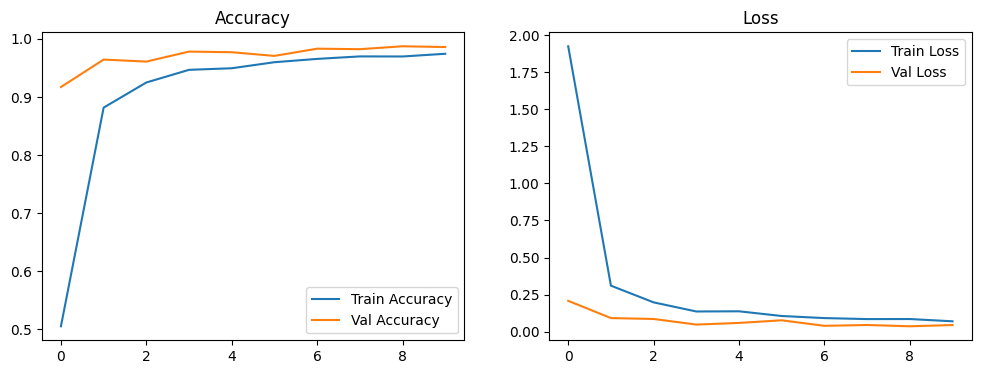

In [45]:
if 'accuracy' in history.history and 'val_accuracy' in history.history:
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.legend()
    plt.title('Accuracy')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title('Loss')
    plt.show()
else:
    print("⚠ Impossible d'afficher les courbes de performance (historique non disponible).")

In [46]:
 predictions = model.predict(X_test)

144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


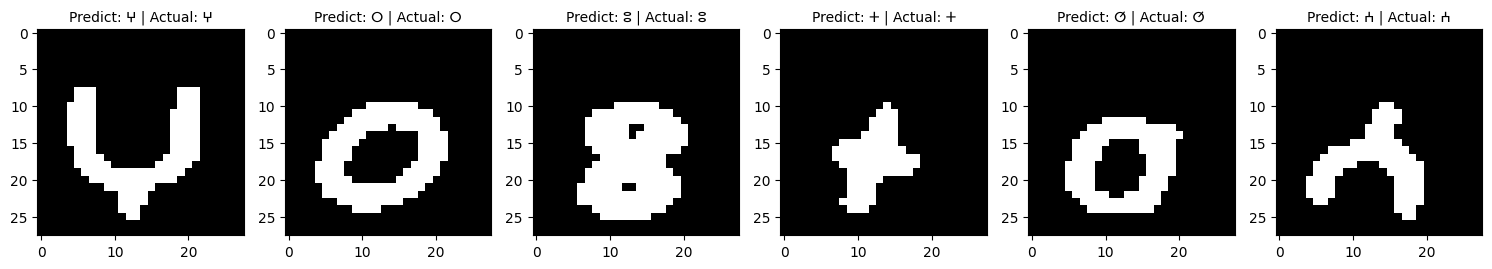

In [60]:
# Define the class names based on the indices we've saved earlier
class_indices = {
    'ⴰ': 1, 'ⴱ': 2, 'ⵛ': 3, 'ⴷ': 4, 'ⴹ': 5, 'ⴻ': 6, 'ⴼ': 7, 'ⴳ': 8, 'ⵀ': 9, 'ⵉ': 10,
    'ⵊ': 11, 'ⴽ': 12, 'ⵍ': 13, 'ⵎ': 14, 'ⵏ': 15, 'ⵄ': 16, 'ⵃ': 17, 'ⵇ': 18, 'ⵔ': 19,
    'ⵕ': 20, 'ⵙ': 21, 'ⵚ': 22, 'ⵜ': 23, 'ⵟ': 24, 'ⵓ': 25, 'ⵖ': 26, 'ⵡ': 27, 'ⵅ': 28,
    'ⵢ': 29, 'ⵣ': 30, 'ⵥ': 31
}

classes = {v: k for k, v in class_indices.items()}
# Visualization of predictions on test images
plot_number = 1
plt.figure(figsize=(15, 5))  # Adjust the size as needed

# Choose 3 random images from the test set to display
for i in np.random.randint(0, len(X_test), 6):
    plt.subplot(1, 6, plot_number)
    plt.grid(False)
    plt.imshow(X_test[i], cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions[i])
    true_label = Y_test[i]
    plt.title(f"Predict: {classes[predicted_label]} | Actual: {classes[true_label]}", fontsize=10)
    plt.tight_layout(pad=1.0)
    plot_number += 1
    
plt.show()

144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


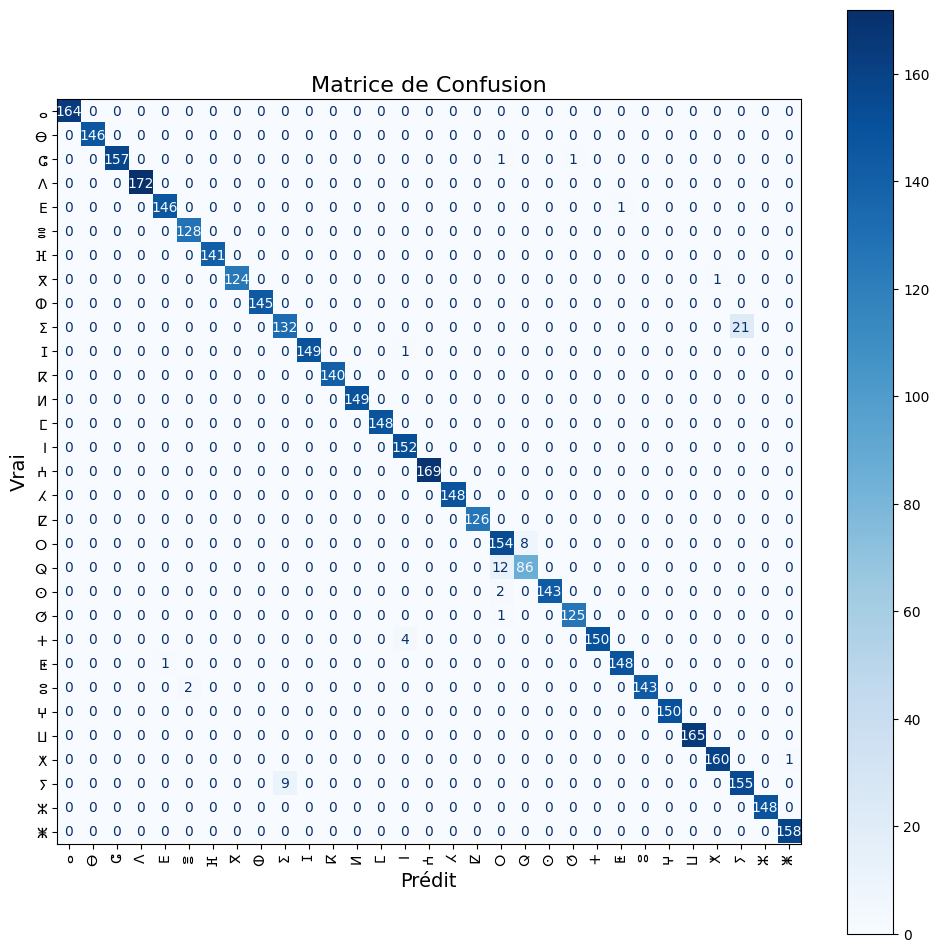

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Prédiction des classes pour les données de test
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = Y_test  # Assurez-vous que Y_test contient les étiquettes de classe réelles sous forme d'entiers

# Mapping des étiquettes numériques aux noms de classes pour y_true et y_pred
y_true_named = [classes[label] for label in y_true]
y_pred_named = [classes[label] for label in y_pred]

# Calcul de la matrice de confusion avec les noms de classes
cm = confusion_matrix(y_true_named, y_pred_named, labels=list(classes.values()))

# Affichage de la matrice de confusion
fig, ax = plt.subplots(figsize=(12, 12))  # Augmente la taille de la figure
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(classes.values()))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
ax.set_title('Matrice de Confusion', fontsize=16)
ax.set_xlabel('Prédit', fontsize=14)
ax.set_ylabel('Vrai', fontsize=14)
plt.show()


In [ ]:
plot_number = 1
plt.figure(figsize=(15, 5))  # Adjust the size as needed

# Choose 3 random images from the test set to display
for i in np.random.randint(0, len(X_test), 6):
    plt.subplot(1, 6, plot_number)
    plt.grid(False)
    plt.imshow(X_test[i], cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions[i])
    true_label = Y_test[i]
    plt.title(f"Predict: {classes[predicted_label]} | Actual: {classes[true_label]}", fontsize=10)
    plt.tight_layout(pad=1.0)
    plot_number += 1
    
plt.show()